<a href="https://colab.research.google.com/github/alheetiaabdullah/my-first-website/blob/main/beardata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'my-first-website'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 159 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 33.23 MiB | 17.79 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Found train images: 76
Found test images : 1
Batch tensor shape: torch.Size([16, 3, 256, 256])


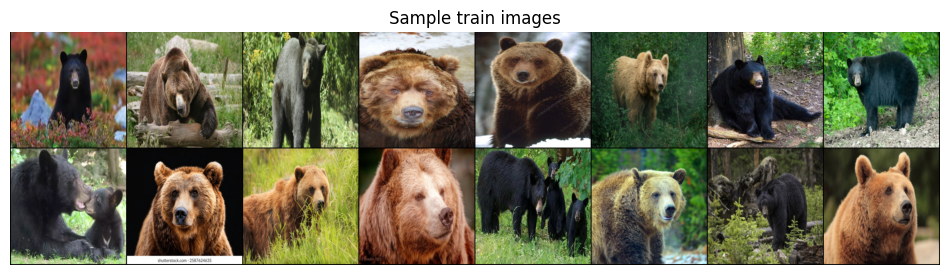

In [2]:
# 1. Clone your repo fresh
!rm -rf my-first-website
!git clone https://github.com/alheetiaabdullah/my-first-website.git

# 2. Imports
import os, glob
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import torchvision

ImageFile.LOAD_TRUNCATED_IMAGES = True  # allow partially saved images

# 3. Paths
train_dir = "my-first-website/animals/train"
test_dir  = "my-first-website/animals/test"

# 4. Transform: resize + tensor
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# 5. Helper: collect images (all extensions)
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def list_images(folder):
    paths = []
    for ext in IMG_EXTS:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        paths.extend(glob.glob(os.path.join(folder, f"*/*{ext}")))  # one level deeper
    return sorted(paths)

# 6. Custom dataset (no need for class subfolders)
class ImagePathDataset(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label

# 7. Create datasets + loaders
train_files = list_images(train_dir)
test_files  = list_images(test_dir)

print("Found train images:", len(train_files))
print("Found test images :", len(test_files))

train_ds = ImagePathDataset(train_files, transform=transform)
test_ds  = ImagePathDataset(test_files,  transform=transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

# 8. Get a batch and show
images, _ = next(iter(train_loader))
print("Batch tensor shape:", images.shape)  # [B, 3, 256, 256]

grid = torchvision.utils.make_grid(images, nrow=8)
plt.figure(figsize=(12,4))
plt.imshow(grid.permute(1,2,0))  # CHW -> HWC
plt.axis("off")
plt.title("Sample train images")
plt.show()
